# ASSIGNMENT 2: Social Media & Network Analysis
**"The impact of AI on Music Sectors (Individual, Communities and Industries)"**

Undergraduate (UG) Group 1
- Joshua Steinke (s4091863)
- Paul Venatt (s4089896)
- Putu Adhi Wiguna (s4097286)

***

**Data Source and Collection**

The dataset was collected from YouTube using the YouTube Data API with the search query `"AI on music"`. YouTube was selected because it contains public discussion around music, artists, AI-generated songs, and audience reactions through both top-level comments and reply threads.

The collected data includes video metadata, comment text, author identifiers, comment IDs, parent comment IDs, timestamps, and reply relationships. These fields support both text analysis and network analysis. The comment text supports NLP and topic modelling, while the author and reply-to-author fields allow construction of a directed user reply network.

In the reply network, each node represents a YouTube user. A directed edge from User A to User B indicates that User A replied to User B. Edge weights represent repeated replies between the same pair of users.

The dataset has some limitations. It only represents videos returned by the selected search query and is affected by YouTube API limits, comment availability, and the public visibility of comments. Non-English comments were removed to improve topic modelling interpretability, which means the final analysis focuses only on English-language discussion.

In [1]:
"""Libraries used"""
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import re
import json
import nltk
import string
from nltk.tokenize import TweetTokenizer
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from scripts.YouTubeProcessing import YouTubeProcessing
import math
import pyLDAvis
import pyLDAvis.lda_model
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from networkx.algorithms.community import greedy_modularity_communities
from collections import Counter
from langdetect import detect, LangDetectException

## 1. Exploratory Data Analysis (EDA)

In [2]:
with open('./data/youtubeFlatComments_AI_on_music.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

dataset = pd.DataFrame(data['comments'])
dataset.head()

,video_id,video_title,channel_id,channel_title,video_published_at,video_view_count,video_like_count,video_comment_count,comment_id,parent_comment_id,comment_type,author_display_name,author_channel_id,text,text_original,like_count,published_at,updated_at,reply_to_author_display_name,reply_to_author_channel_id
0,Sbv0iX_EyLM,AI Music is Not Music - Adam Neely,UC7kIy8fZavEni8Gzl8NLjOQ,Alex O'Connor,2026-05-13T15:31:35Z,229348,8458,3861,Ugz_vLToQloKib1Dsmt4AaABAg,NaN,top_level,@foxmocs6443,UCinA3pJ4_XChanp3nvpfNsw,Never could have predicted this crossover. Two...,Never could have predicted this crossover. Two...,1441,2026-05-13T15:32:19Z,2026-05-13T15:32:19Z,NaN,NaN
1,Sbv0iX_EyLM,AI Music is Not Music - Adam Neely,UC7kIy8fZavEni8Gzl8NLjOQ,Alex O'Connor,2026-05-13T15:31:35Z,229348,8458,3861,Ugz_vLToQloKib1Dsmt4AaABAg.AWkg3VfSPEZAWkhCufgK72,Ugz_vLToQloKib1Dsmt4AaABAg,reply,@MidnightUnity,UCdisatKsUEaCeliNJ6BdKZg,"I was about to say two of my favourite nerds, ...","I was about to say two of my favourite nerds, ...",28,2026-05-13T15:42:20Z,2026-05-13T15:42:20Z,@foxmocs6443,UCinA3pJ4_XChanp3nvpfNsw
2,Sbv0iX_EyLM,AI Music is Not Music - Adam Neely,UC7kIy8fZavEni8Gzl8NLjOQ,Alex O'Connor,2026-05-13T15:31:35Z,229348,8458,3861,Ugz_vLToQloKib1Dsmt4AaABAg.AWkg3VfSPEZAWkhSyhPznS,Ugz_vLToQloKib1Dsmt4AaABAg,reply,@AdımızAdımız,UCRELhN7padwcwT94a0m0tnQ,fr,fr,1,2026-05-13T15:44:32Z,2026-05-13T15:44:32Z,@foxmocs6443,UCinA3pJ4_XChanp3nvpfNsw
3,Sbv0iX_EyLM,AI Music is Not Music - Adam Neely,UC7kIy8fZavEni8Gzl8NLjOQ,Alex O'Connor,2026-05-13T15:31:35Z,229348,8458,3861,Ugz_vLToQloKib1Dsmt4AaABAg.AWkg3VfSPEZAWkhd5JSn27,Ugz_vLToQloKib1Dsmt4AaABAg,reply,@mymasmith7848,UC7ps19AcOCVsJB3MzW_qsmQ,"Yeeeeehah, I am so eagerly the next two hours ...","Yeeeeehah, I am so eagerly the next two hours ...",2,2026-05-13T15:46:03Z,2026-05-13T15:46:03Z,@foxmocs6443,UCinA3pJ4_XChanp3nvpfNsw
4,Sbv0iX_EyLM,AI Music is Not Music - Adam Neely,UC7kIy8fZavEni8Gzl8NLjOQ,Alex O'Connor,2026-05-13T15:31:35Z,229348,8458,3861,Ugz_vLToQloKib1Dsmt4AaABAg.AWkg3VfSPEZAWkjpDEB6Po,Ugz_vLToQloKib1Dsmt4AaABAg,reply,@zlquis,UCbhxNik1HRXNuFjBb2nXMvg,Literally my 2 favourite content creators. I'm...,Literally my 2 favourite content creators. I'm...,9,2026-05-13T16:05:11Z,2026-05-13T16:05:11Z,@foxmocs6443,UCinA3pJ4_XChanp3nvpfNsw


In [3]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 14342 entries, 0 to 14341
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   video_id                      14342 non-null  str  
 1   video_title                   14342 non-null  str  
 2   channel_id                    14342 non-null  str  
 3   channel_title                 14342 non-null  str  
 4   video_published_at            14342 non-null  str  
 5   video_view_count              14342 non-null  int64
 6   video_like_count              14342 non-null  int64
 7   video_comment_count           14342 non-null  int64
 8   comment_id                    14342 non-null  str  
 9   parent_comment_id             12011 non-null  str  
 10  comment_type                  14342 non-null  str  
 11  author_display_name           14342 non-null  str  
 12  author_channel_id             14342 non-null  str  
 13  text                          14342 non-nu

## 2. Data Cleaning

### 2.1. Keeping English Comments Only

In [4]:
def check_language(text):
    """Check if comments are in English"""
    try:
        return detect(str(text))
    except LangDetectException:
        return 'unknown'

dataset['language'] = dataset['text'].apply(check_language)
dataset['language'].value_counts().head(10)

language
en         12345
unknown      261
tl           207
so           136
af           105
nl           104
de           100
fr           100
cy            98
id            88
Name: count, dtype: int64

Non-English comments will be removed from the dataset since we will only be working with English comments.

In [5]:
# To confirm if dataset only contains English comments
dataset = dataset[dataset['language'] == 'en']
dataset['language'].unique()

<StringArray>
['en']
Length: 1, dtype: str

### 2.2. Removing Very Short Comments

Very short comments (e.g., comments with less than 3 words) does not really add much meaning regarding users semantic. Hence, they are removed from the dataset.

In [6]:
# Keeps comments with length of 3 or more words
dataset = dataset[dataset['text'].str.split().apply(len) >= 3].reset_index(drop=True)

In [7]:
def clean_comments(text):
    """
    Function to clean comments, the process goes as:
    
    1. Convert comments to use all lowercase
    2. Remove any URLs
    3. Remove any YouTube-style mentions/handles if present
    4. Remove common unicode punctuation
    5. Keeps letters and spaces only
    6. Remove extra whitespaces
    """
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[\u2018\u2019\u201c\u201d\u2014]', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Place the cleaned text comments into a separate column, keep the original text
dataset['cleaned_text'] = dataset['text'].apply(clean_comments)
dataset[['text', 'cleaned_text']].head()

,text,cleaned_text
0,Never could have predicted this crossover. Two...,never could have predicted this crossover two ...
1,"I was about to say two of my favourite nerds, ...",i was about to say two of my favourite nerds b...
2,"Yeeeeehah, I am so eagerly the next two hours ...",yeeeeehah i am so eagerly the next two hours o...
3,Literally my 2 favourite content creators. I'm...,literally my favourite content creators i m ev...
4,"Alex is a pretty good musician himself, so I'm...",alex is a pretty good musician himself so i m ...


## 3. Tokenise and Remove Stopwords

In [8]:
nltk.download('stopwords')

tokeniser = TweetTokenizer()
stemmer = PorterStemmer()

stop_words = stopwords.words('english') + list(string.punctuation)

# Some additional stopwords that might be present in the comments but don't add much meanings
add_stopwords = [
    'ai', 'music', 'song', 'songs', 'video',
    'like', 'just', 'get', 'would', 'could',
    'people', 'peopl', 'make', 'use', 'thing',
    'think', 'one', 'go', 'going', 'want',
    'look', 'sound', 'good', 'really', 'realli',
    'even', 'much', 'say', 'know', 'see', 'also',
    'im', 'ive', 'dont', 'cant', 'youre', 'thats'
]

# Apply the additional stopwords into the base NLTK's English stopwords
stop_words = set(stop_words + add_stopwords)

[nltk_data] Downloading package stopwords to /Users/adhi/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [9]:
def tokenise_text(text):
    """
    Function to tokenise the cleaned text comments
    """
    tokens = tokeniser.tokenize(str(text).lower())
    processed_tokens = []
    for token in tokens:
        token = token.strip()
        if not token:
            continue
        if token in stop_words:
            continue
        if token.isdigit():
            continue
        if re.search(r'[a-zA-Z]', token) is None:
            continue

        token = stemmer.stem(token)
        if token not in stop_words and len(token) > 1:
            processed_tokens.append(token)

    return processed_tokens

# Apply the tokenisation onto the cleaned texts
dataset['tokens'] = dataset['cleaned_text'].apply(tokenise_text)

# Join the tokens together, place it into a new column
dataset['processed_text'] = dataset['tokens'].apply(lambda tokens: ' '.join(tokens))

# Add token counts column
dataset['tokens_count'] = dataset['tokens'].apply(len)

dataset[['text', 'cleaned_text', 'tokens', 'processed_text']].head()

,text,cleaned_text,tokens,processed_text
0,Never could have predicted this crossover. Two...,never could have predicted this crossover two ...,"[never, predict, crossov, two, favorit, studi,...",never predict crossov two favorit studi combin
1,"I was about to say two of my favourite nerds, ...",i was about to say two of my favourite nerds b...,"[two, favourit, nerd, studi, actual, nicer, wa...",two favourit nerd studi actual nicer way word ...
2,"Yeeeeehah, I am so eagerly the next two hours ...",yeeeeehah i am so eagerly the next two hours o...,"[yeeeeehah, eagerli, next, two, hour, fine, li...",yeeeeehah eagerli next two hour fine listen
3,Literally my 2 favourite content creators. I'm...,literally my favourite content creators i m ev...,"[liter, favourit, content, creator, adam, tour...",liter favourit content creator adam tour next ...
4,"Alex is a pretty good musician himself, so I'm...",alex is a pretty good musician himself so i m ...,"[alex, pretti, musician, surpris]",alex pretti musician surpris


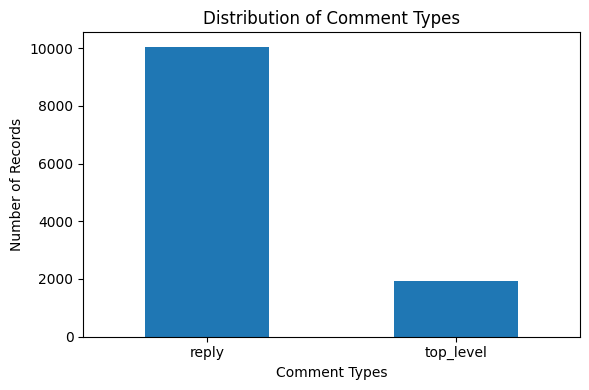

In [10]:
comment_types = dataset['comment_type'].value_counts()

# Plot the comment type counts
plt.figure(figsize=(6, 4))
comment_types.plot(kind='bar')
plt.title('Distribution of Comment Types')
plt.xlabel('Comment Types')
plt.ylabel('Number of Records')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

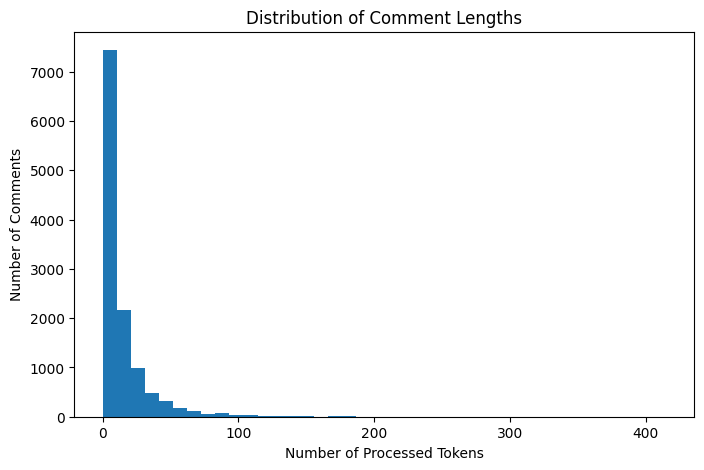

In [ ]:
# Plot comment tokens length distribution
plt.figure(figsize=(8, 5))
plt.hist(dataset['tokens_count'], bins=40)
plt.title('Distribution of Comment Lengths')
plt.xlabel('Number of Processed Tokens')
plt.ylabel('Number of Comments')
plt.show()

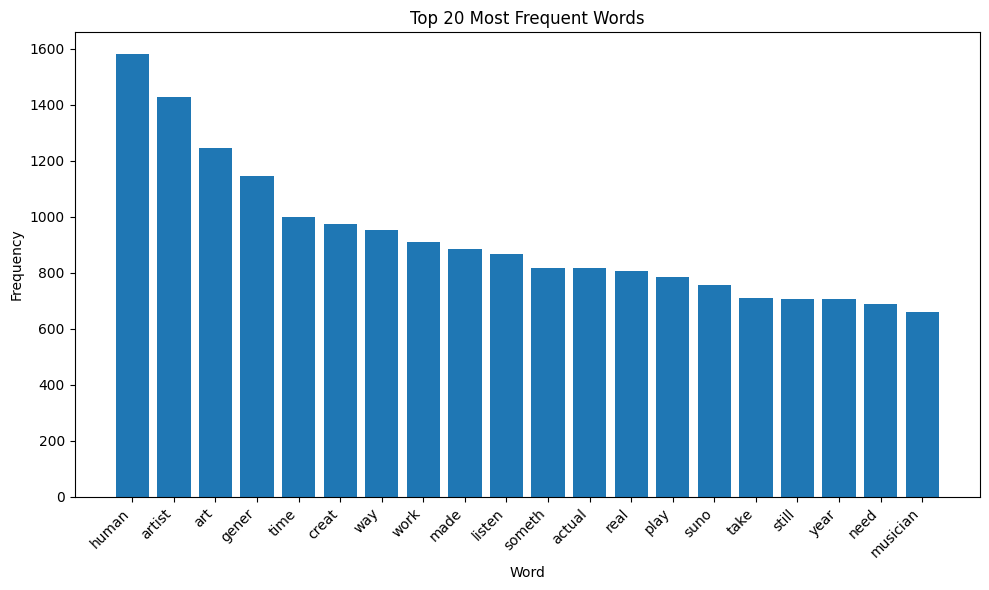

In [14]:
# Plot top 20 most used words
all_tokens = []
for tokens in dataset['tokens']:
    all_tokens.extend(tokens)
word_freq = Counter(all_tokens)

top_words = pd.DataFrame(
    word_freq.most_common(20),
    columns=['word', 'frequency']
)

# Plot
plt.figure(figsize=(10, 6))
plt.bar(top_words['word'], top_words['frequency'])
plt.title('Top 20 Most Frequent Words')
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Topic Modelling (LDA)

We use Latent Dirichlet Allocation (LDA) to discover latent topics discussed across cleaned English YouTube comments and replies about AI and music. This helps identify what users are discussing, such as AI music tools, human creativity, copyright, and industry disruption. The topic labels are later connected with user communities in the reply network.

In [17]:
dataset = dataset[dataset['processed_text'].str.strip() != ''].reset_index(drop=True)

vectorizer = CountVectorizer(max_df=0.9, min_df=5, max_features=1000)

"""
@dtm: Document Term Matrix

By observing the shape:
Rows = comments
Columns = selected words/features
"""
dtm = vectorizer.fit_transform(dataset['processed_text'])
print('Document-term matrix shape:', dtm.shape)

Document-term matrix shape: (11884, 1000)


In [18]:
num_topics = 5

# Set and fit the LDA model
LDA_model = LatentDirichletAllocation(n_components=num_topics, random_state=42, learning_method='batch')
LDA_model.fit(dtm)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",-1
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


In [19]:
# Get list of words from CountVectorizer vocabulary
feat_names = vectorizer.get_feature_names_out()

def display_topics(model, feature_names, number_of_words=15):
    """Prints the most associated words for each topic."""
    for topic_id, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[-number_of_words:][::-1]
        top_words = [feature_names[i] for i in top_word_indices]

        print(f'Topic {topic_id}:')
        print(', '.join(top_words))
        print()

display_topics(model=LDA_model, feature_names=feat_names, number_of_words=15)

Topic 0:
suno, write, lyric, creat, play, record, gener, produc, musician, year, instrument, differ, prompt, tool, way

Topic 1:
artist, listen, time, year, take, countri, real, musician, day, need, alreadi, everi, mani, gener, back

Topic 2:
art, human, gener, made, artist, actual, creat, content, slop, care, better, point, still, creativ, someth

Topic 3:
thank, lol, comment, love, bro, copyright, man, got, yeah, actual, tri, right, well, gonna, oh

Topic 4:
human, live, mean, work, someth, way, new, point, time, learn, real, anyth, us, world, life



### 4.1. pyLDAvis

pyLDAvis provides an interactive visualisation of the topic model.
Each bubble represents a topic — larger bubbles indicate more prevalent topics,
and the distance between bubbles reflects how distinct the topics are from each other.

In [ ]:
"""Displaying pyLDAvis panel"""
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare(LDA_model, dtm, vectorizer, mds='tsne')

pyLDAvis.display(panel)

### 4.2. Word Clouds

We visualise each topic as a word cloud, where larger words have a stronger association with that topic. This makes the themes easier to interpret at a glance.

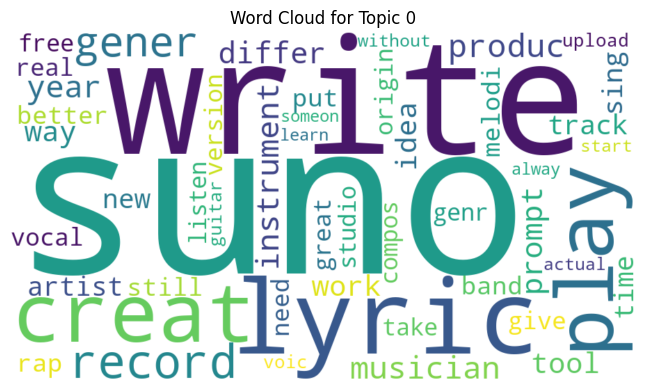

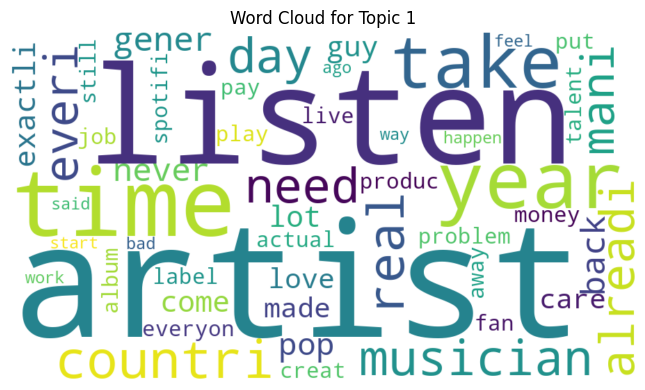

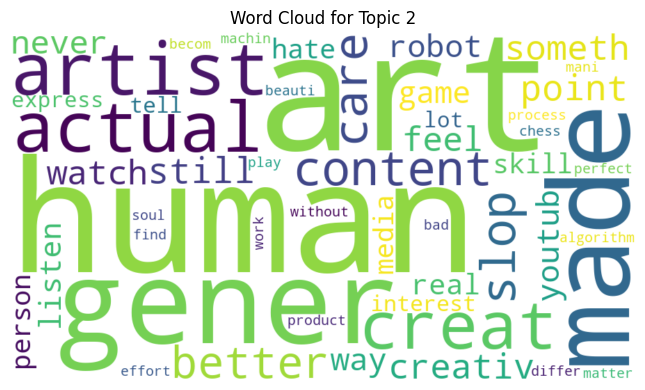

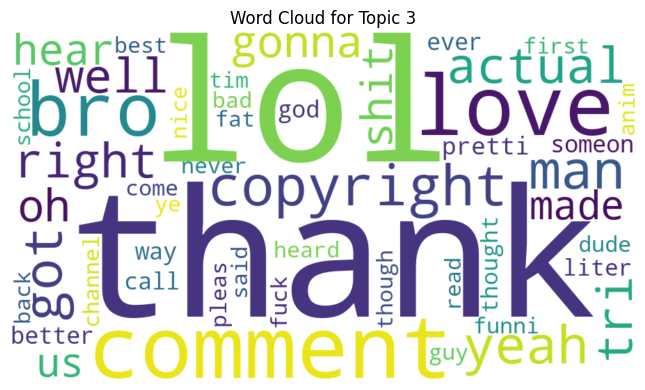

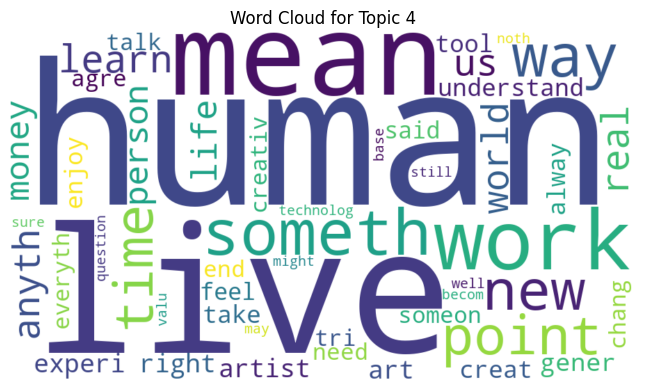

In [27]:
def plot_word_cloud(model, feature_names, topic_idx, number_of_words=50):
    """Function to display the word cloud to identify dominant topics"""
    topic = model.components_[topic_idx]
    top_word_indices = topic.argsort()[-number_of_words:][::-1]
    word_weights = {feature_names[i]: topic[i] for i in top_word_indices}

    # Configure word cloud settings
    wordcloud = WordCloud(width=900, height=500, background_color='white').generate_from_frequencies(word_weights)

    # Plot
    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Word Cloud for Topic {topic_idx}')
    plt.tight_layout()
    plt.show()

# Display and generate the word cloud for topics
for topic_index in range(num_topics):
    plot_word_cloud(
        model=LDA_model,
        feature_names=feat_names,
        topic_idx=topic_index,
        number_of_words=50
    )

In [28]:
# Saving the topic words into a table
topics = []
for topic_idx, topic in enumerate(LDA_model.components_):
    top_word_indices = topic.argsort()[-12:][::-1]

    for word_rank, word_idx in enumerate(top_word_indices, start=1):
        topics.append({
            'topic': topic_idx,
            'rank': word_rank,
            'word': feat_names[word_idx],
            'weight': topic[word_idx]
        })

# Put the collected topics into a DataFrame
topics_data = pd.DataFrame(topics)
topics_data.head(10)

,topic,rank,word,weight
0,0,1,suno,745.610740
1,0,2,write,541.045986
2,0,3,lyric,445.789727
3,0,4,creat,422.580380
4,0,5,play,408.130034
5,0,6,record,395.837585
6,0,7,gener,317.834865
7,0,8,produc,308.292639
8,0,9,musician,301.266918
9,0,10,year,299.044847


### 4.3. Assigning a Dominant Topic to Each Comment

We assign each top-level comment its dominant topic — the topic
that the LDA model assigns the highest probability to.

This lets us later cross-reference topics with the network analysis,
for example by seeing which topics are most associated with
highly central or influential users.

In [34]:
"""
Transform the Document Term Matrix to get the topic distribution
Each row is a comment, each column is a topic probability
"""
topic_dist = LDA_model.transform(dtm)

print('Topic distribution matrix:')
print(f'{topic_dist.shape[0]} comments')
print(f'{topic_dist.shape[1]} topics')

# Add dominant topics and it's probability into a new column in the dataset
dataset['dominant_topic'] = topic_dist.argmax(axis=1)
dataset['dominant_topic_probability'] = topic_dist.max(axis=1)
dataset[['text', 'processed_text', 'dominant_topic', 'dominant_topic_probability']].head()

Topic distribution matrix:
11884 comments
5 topics


,text,processed_text,dominant_topic,dominant_topic_probability
0,Never could have predicted this crossover. Two...,never predict crossov two favorit studi combin,1,0.503143
1,"I was about to say two of my favourite nerds, ...",two favourit nerd studi actual nicer way word ...,3,0.884000
2,"Yeeeeehah, I am so eagerly the next two hours ...",yeeeeehah eagerli next two hour fine listen,0,0.862988
3,Literally my 2 favourite content creators. I'm...,liter favourit content creator adam tour next ...,3,0.557380
4,"Alex is a pretty good musician himself, so I'm...",alex pretti musician surpris,3,0.509121


In [37]:
# Get a summarisation of the topic distribution
topic_summary = (dataset['dominant_topic'].value_counts().sort_index().reset_index())
topic_summary.columns = ['topic', 'number_of_comments']
topic_summary['percentage'] = (topic_summary['number_of_comments'] / len(dataset) * 100).round(2)

topic_summary

,topic,number_of_comments,percentage
0,0,2431,20.46
1,1,2229,18.76
2,2,2041,17.17
3,3,2759,23.22
4,4,2424,20.40


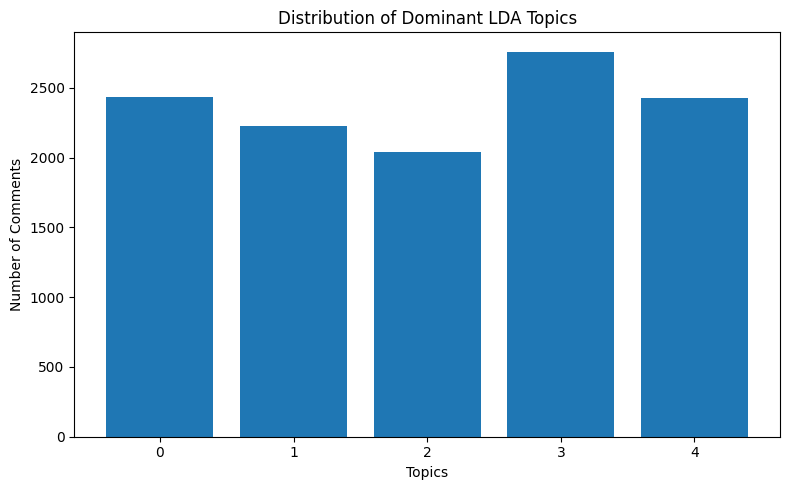

In [38]:
"""Plotting dominant topics distribution"""
plt.figure(figsize=(8, 5))
plt.bar(
    topic_summary['topic'].astype(str),
    topic_summary['number_of_comments']
)

plt.title('Distribution of Dominant LDA Topics')
plt.xlabel('Topics')
plt.ylabel('Number of Comments')
plt.tight_layout()
plt.show()

Based on the generate Word Clouds, a topic sentence was manually labelled for each topic ID.

In [43]:
"""Manually labelling the topic based on generated word clouds"""
topic_labels = {
    0: 'AI-assisted songwriting and music production',
    1: 'Music industry and artist disruption',
    2: 'Human creativity versus AI-generated content',
    3: 'Copyright, copying, and audience reactions',
    4: 'Human value, learning, and adaptation to AI'
}

dataset['topic_label'] = dataset['dominant_topic'].map(topic_labels)

After identifying dominant discussion topics using LDA, the analysis moves to the interaction structure of the YouTube comments. Since the dataset contains a large number of replies, a directed weighted user reply network was constructed. This allows the project to identify influential users and interaction communities, then compare whether different communities focus on different AI-music topics.

## 5. User Replies Network

After assigning each comment a dominant LDA topic, the next stage is to analyse the interaction structure of the YouTube discussion. Since the dataset contains many replies, a directed weighted user reply network was constructed. In this network, each node represents a YouTube user, and each directed edge represents one user replying to another user. Edge weights represent the number of replies between the same pair of users.

In [ ]:
"""Filtering user reply records"""
replies_data = dataset[
    (dataset['comment_type'] == 'reply') &
    (dataset['author_channel_id'].notna()) &
    (dataset['reply_to_author_channel_id'].notna())
].copy()

# Remove self-replies
replies_data = replies_data[
    replies_data['author_channel_id'] != replies_data['reply_to_author_channel_id']
].copy()

print('Number of reply rows:', len(replies_data))
print('Unique replying users:', replies_data['author_channel_id'].nunique())
print('Unique replied-to users:', replies_data['reply_to_author_channel_id'].nunique())

Number of reply rows: 9549
Unique replying users: 5932
Unique replied-to users: 895


In [45]:
# Building edge list
edge_data = (
    replies_data
    .groupby([
        'author_channel_id',
        'reply_to_author_channel_id'
    ])
    .agg(
        weight=('comment_id', 'count'),
        source_name=('author_display_name', 'first'),
        target_name=('reply_to_author_display_name', 'first')
    )
    .reset_index()
    .rename(columns={
        'author_channel_id': 'source',
        'reply_to_author_channel_id': 'target'
    })
)

edge_data.head()

,source,target,weight,source_name,target_name
0,UC-143ND7KXdjfcqMXbZH5Ng,UCZllv4L7S3t16kgLuN33NiA,1,@Tooruofficial1,@GramGramAnimations
1,UC-1yf1p7WRvY3z2L4MamGHg,UCgfZdkzvVUHf4vKPj-R4_7A,1,@Page-Humbuckers1973,@controlledburst
2,UC-3GMsrNch7u7837iLI26bA,UCPTa2aqVGv1bxCMlwkWOxYA,1,@vocecaiunocontodomalakoi7541,@ZBspicey
3,UC-3tABkXUfdRJFQ1Zx39MbA,UC9-tyozbTOKwJPZ6lEvAb4g,2,@jackweitzman6697,@foxyrand
4,UC-5zrhkAivIM0jKEWyLgVJg,UCxB219ufjxNVadCO3GPpotA,1,@AliBreee,@therealunclebbq


In [ ]:
# Building directed weight graph
G = nx.from_pandas_edgelist(
    edge_data,
    source='source',
    target='target',
    edge_attr=['weight', 'source_name', 'target_name'],
    create_using=nx.DiGraph()
)

print('Number of nodes:', G.number_of_nodes())
print('Number of edges:', G.number_of_edges())
print('Network density:', nx.density(G))

Number of nodes: 6768
Number of edges: 7403
Network density: 0.00016164088622263307


The low network density is expected for a YouTube reply network because most users interact with only a small number of other users. This suggests that the discussion is sparse rather than fully connected, which is common in social media interaction networks.

## 6. SNA Centrality Measures

Centrality measures were calculated to identify structurally important users in the reply network. Weighted in-degree identifies users who received many replies, weighted out-degree identifies users who actively replied to others, PageRank identifies users who are influential within the reply structure, and betweenness centrality identifies users who connect different parts of the network.

In [47]:
# Weighted in-degree and out-degree
in_degree = dict(G.in_degree(weight='weight'))
out_degree = dict(G.out_degree(weight='weight'))

# PageRank
pagerank = nx.pagerank(G, weight='weight')

# Convert edge weight into distance for betweenness centrality
# Higher reply frequency = stronger connection = shorter distance
for u, v, edge_attributes in G.edges(data=True):
    edge_attributes['distance'] = 1 / edge_attributes['weight']

# Betweenness
betweenness = nx.betweenness_centrality(G, weight='distance', normalized=True)

In [48]:
# Creating centrality table that includes usernames
user_names = {}
for _, row in replies_data.iterrows():
    user_names[row['author_channel_id']] = row['author_display_name']
    user_names[row['reply_to_author_channel_id']] = row['reply_to_author_display_name']

centrality_data = pd.DataFrame({
    'id': list(G.nodes()),
    'username': [user_names.get(node, node) for node in G.nodes()],
    'weighted_in_degree': [in_degree.get(node, 0) for node in G.nodes()],
    'weighted_out_degree': [out_degree.get(node, 0) for node in G.nodes()],
    'pagerank': [pagerank.get(node, 0) for node in G.nodes()],
    'betweenness': [betweenness.get(node, 0) for node in G.nodes()]
})

centrality_data.head()

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness
0,UC-143ND7KXdjfcqMXbZH5Ng,@Tooruofficial1,0,1,0.000081,0.000000
1,UCZllv4L7S3t16kgLuN33NiA,@GramGramAnimations,96,1,0.006908,0.000005
2,UC-1yf1p7WRvY3z2L4MamGHg,@Page-Humbuckers1973,0,1,0.000081,0.000000
3,UCgfZdkzvVUHf4vKPj-R4_7A,@controlledburst,65,0,0.004856,0.000000
4,UC-3GMsrNch7u7837iLI26bA,@vocecaiunocontodomalakoi7541,0,1,0.000081,0.000000


In [49]:
# Top users based on weighted in degree centrality
centrality_data.sort_values('weighted_in_degree', ascending=False).head(10)

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness
515,UC4PIiYewI1YGyiZvgNlJNrA,@CharlesCornellStudios,100,4,0.004830,0.000019
122,UCOrK28-rchatUNaXf8QgBPw,@halsti99,97,0,0.003390,0.000000
1,UCZllv4L7S3t16kgLuN33NiA,@GramGramAnimations,96,1,0.006908,0.000005
94,UCUJDTsUzE0s6xAwdNlwfXCA,@Prog-t9d,96,0,0.004457,0.000000
62,UCAiYGga6xkRUnXYhaGd0WNA,@PuRpLe0MiSt,95,0,0.004936,0.000000
171,UC93SAoFOTG75UTTKa7CTCrw,@andriypredmyrskyy7791,95,0,0.002301,0.000000
368,UC8j3fdKGM2d-rv1qFp_QxLw,@cbobschloss,93,0,0.004663,0.000000
224,UCQFtmcpgr7NkcvuaCCJdViA,@believershope,93,0,0.003700,0.000000
279,UC7wIrwsFD-4n9m6I-NxA5yA,@MattEdwards1,90,0,0.003790,0.000000
118,UCbpmPHT679KOANvgVKg1DzA,@3DThrills,90,0,0.003959,0.000000


In [50]:
# Top users based on weighted out degree centrality
centrality_data.sort_values('weighted_out_degree', ascending=False).head(10)

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness
2030,UCmeU2DYiVy80wMBGZzEWnbw,@PaulJLipsky,8,50,0.000622,0.000009
5933,UCrEJc2qvac8VfdVySj00t3w,@TevezNedro,0,40,0.000081,0.000000
6687,UCzFQwsVY0lcAOoorfABJ4_w,@EliMercerOfficial,0,37,0.000081,0.000000
3823,UCXkIMilviTtF_EFYC4ylOJg,@aahhhhhhhhhhhhh,0,35,0.000081,0.000000
2849,UCOQfLCVu3VCrdwA_kqWtIEQ,@yuna17994,0,25,0.000081,0.000000
6253,UCuajBd4igtzl5xjvKS9mYtw,@conspiracymusic,0,25,0.000081,0.000000
6063,UCsN7_WaJWqh1MCgGfye3_ew,@ReactInfo54,0,24,0.000081,0.000000
5860,UCqRNyvicCCqLIySuLK8DdIQ,@eightcoins4401,0,24,0.000081,0.000000
3282,UCSh5zO3a_AZWmzukVmwvVJQ,@RusticRoadCountry,0,24,0.000081,0.000000
4645,UCf658Qpw_ou8oL_mityeP-A,@broughttoyouopmsoulrevival,0,23,0.000081,0.000000


In [51]:
# Top users based on PageRank centrality
centrality_data.sort_values('pagerank', ascending=False).head(10)

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness
1,UCZllv4L7S3t16kgLuN33NiA,@GramGramAnimations,96,1,0.006908,0.000005
390,UCRwX7nPX7kMbN8MEHSZG3ZQ,@Ellary_Rosewood,22,0,0.006652,0.000000
222,UCZJWUueXq2Gbvr8znMnBvzA,@sillybilly1489,79,0,0.005257,0.000000
39,UCKxT19NqLN5AYl4imxG2E5Q,@nathanbanks2354,79,0,0.005107,0.000000
62,UCAiYGga6xkRUnXYhaGd0WNA,@PuRpLe0MiSt,95,0,0.004936,0.000000
3,UCgfZdkzvVUHf4vKPj-R4_7A,@controlledburst,65,0,0.004856,0.000000
515,UC4PIiYewI1YGyiZvgNlJNrA,@CharlesCornellStudios,100,4,0.004830,0.000019
368,UC8j3fdKGM2d-rv1qFp_QxLw,@cbobschloss,93,0,0.004663,0.000000
167,UCOEkCtSMFWVm3en3618lzcA,@davisthedaviskids2574,72,0,0.004628,0.000000
9,UCxB219ufjxNVadCO3GPpotA,@therealunclebbq,80,0,0.004539,0.000000


In [52]:
# Top users based on betweenness centrality
centrality_data.sort_values('betweenness', ascending=False).head(10)

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness
515,UC4PIiYewI1YGyiZvgNlJNrA,@CharlesCornellStudios,100,4,0.004830,0.000019
730,UCfEJZmjVvEXt0RWURwP5Uag,@staticloop-o8r,29,9,0.002408,0.000017
305,UC7epYXoxGQlErIpBOYoCj9A,@AIAutomationLabs,34,17,0.002177,0.000010
2030,UCmeU2DYiVy80wMBGZzEWnbw,@PaulJLipsky,8,50,0.000622,0.000009
7,UC9-tyozbTOKwJPZ6lEvAb4g,@foxyrand,37,1,0.003425,0.000007
1,UCZllv4L7S3t16kgLuN33NiA,@GramGramAnimations,96,1,0.006908,0.000005
114,UCA9ddiLbmBNN1pDlEGDKiuw,@MergoGreat1,60,7,0.002288,0.000004
553,UCkmyqYWJ0x-nZjRMH6rI9tw,@NeoSoulReimahe,5,19,0.000430,0.000002
439,UCyGuZR2aP0RDpbXRhJycmRQ,@Burnrate,33,2,0.001627,0.000002
1812,UCr2Pmqtaz9Uk9yK7Io_m0RQ,@AlekseyMaksimovichPeshkov,14,4,0.000868,0.000001


In [ ]:
# Saving centrality data for later use
centrality_data.to_csv('./data/replyNetworkCentrality.csv', index=False)

## 7. Community Detection

Community detection was applied to identify groups of users who interacted more closely with each other. The directed reply network was converted to an undirected graph for community detection because the aim was to find interaction clusters rather than model reply direction. Edge weights were retained so that repeated interactions between users contributed more strongly to community formation.

In [54]:
G_undirected = G.to_undirected()
communities = greedy_modularity_communities(G_undirected, weight='weight')

print('Number of communities detected:', len(communities))
print('Largest community size:', len(max(communities, key=len)))

Number of communities detected: 251
Largest community size: 443


In [55]:
# Assigning community labels to user
community_lookup = {}
for id, nodes in enumerate(communities):
    for node in nodes:
        community_lookup[node] = id

centrality_data['community'] = centrality_data['id'].map(community_lookup)
centrality_data.head()

,id,username,weighted_in_degree,weighted_out_degree,pagerank,betweenness,community
0,UC-143ND7KXdjfcqMXbZH5Ng,@Tooruofficial1,0,1,0.000081,0.000000,1
1,UCZllv4L7S3t16kgLuN33NiA,@GramGramAnimations,96,1,0.006908,0.000005,1
2,UC-1yf1p7WRvY3z2L4MamGHg,@Page-Humbuckers1973,0,1,0.000081,0.000000,7
3,UCgfZdkzvVUHf4vKPj-R4_7A,@controlledburst,65,0,0.004856,0.000000,7
4,UC-3GMsrNch7u7837iLI26bA,@vocecaiunocontodomalakoi7541,0,1,0.000081,0.000000,11


In [ ]:
# Get a summary of communities
community_summary = (
    centrality_data
    .groupby('community')
    .agg(
        number_of_users=('id', 'count'),
        avg_pagerank=('pagerank', 'mean'),
        max_pagerank=('pagerank', 'max'),
        avg_betweenness=('betweenness', 'mean'),
        max_betweenness=('betweenness', 'max')
    )
    .sort_values('number_of_users', ascending=False)
    .reset_index()
)

community_summary.head(10)

,community,number_of_users,avg_pagerank,max_pagerank,avg_betweenness,max_betweenness
0,0,443,0.000148,0.004936,9.860481e-11,4.368193e-08
1,1,442,0.000183,0.006908,1.117249e-07,1.879415e-05
2,2,342,0.000153,0.003959,4.534235e-09,6.552290e-07
3,3,323,0.000144,0.003259,3.583812e-09,8.517976e-07
4,4,288,0.000141,0.002301,3.640161e-09,7.644338e-07
5,5,282,0.000152,0.004539,1.332144e-08,3.756646e-06
6,6,278,0.000147,0.004457,6.285170e-10,1.747277e-07
7,7,269,0.000155,0.004856,0.000000e+00,0.000000e+00
8,8,264,0.000146,0.002135,3.309237e-09,2.839325e-07
9,9,237,0.000143,0.002071,9.215597e-11,2.184097e-08


In [57]:
# Add community labels back to the dataset
dataset['author_community'] = dataset['author_channel_id'].map(community_lookup)
dataset[['author_display_name', 'comment_type', 'topic_label', 'author_community', 'text']].head()

,author_display_name,comment_type,topic_label,author_community,text
0,@foxmocs6443,top_level,Music industry and artist disruption,46.0,Never could have predicted this crossover. Two...
1,@MidnightUnity,reply,"Copyright, copying, and audience reactions",46.0,"I was about to say two of my favourite nerds, ..."
2,@mymasmith7848,reply,AI-assisted songwriting and music production,46.0,"Yeeeeehah, I am so eagerly the next two hours ..."
3,@zlquis,reply,"Copyright, copying, and audience reactions",46.0,Literally my 2 favourite content creators. I'm...
4,@CamxCam.,reply,"Copyright, copying, and audience reactions",46.0,"Alex is a pretty good musician himself, so I'm..."


## 8. Connecting Communities to LDA Topics

After detecting user communities, the community labels were mapped back to the comment dataset. This allows comparison of the dominant LDA topics across different interaction communities, showing whether different user groups focus on different aspects of AI's impact on music.

In [ ]:
# Topic distribution by community
community_topic_summary = (
    dataset
    .dropna(subset=['author_community'])
    .groupby(['author_community', 'topic_label'])
    .size()
    .reset_index(name='comment_count')
)

# Convert it into percentages for each community
community_topic_summary['community_total'] = (
    community_topic_summary
    .groupby('author_community')['comment_count']
    .transform('sum')
)

community_topic_summary['percentage'] = (
    community_topic_summary['comment_count'] /
    community_topic_summary['community_total'] * 100
).round(2)

community_topic_summary.head()

,author_community,topic_label,comment_count,community_total,percentage
0,0.0,AI-assisted songwriting and music production,101,742,13.61
1,0.0,"Copyright, copying, and audience reactions",143,742,19.27
2,0.0,Human creativity versus AI-generated content,156,742,21.02
3,0.0,"Human value, learning, and adaptation to AI",216,742,29.11
4,0.0,Music industry and artist disruption,126,742,16.98


In [60]:
# Top-level topic per community
top_topic_per_community = (
    community_topic_summary
    .sort_values(['author_community', 'comment_count'], ascending=[True, False])
    .groupby('author_community')
    .head(1)
    .reset_index(drop=True)
)

top_topic_per_community.head(10)

,author_community,topic_label,comment_count,community_total,percentage
0,0.0,"Human value, learning, and adaptation to AI",216,742,29.11
1,1.0,"Human value, learning, and adaptation to AI",242,756,32.01
2,2.0,AI-assisted songwriting and music production,196,702,27.92
3,3.0,AI-assisted songwriting and music production,213,641,33.23
4,4.0,"Human value, learning, and adaptation to AI",266,700,38.00
5,5.0,"Copyright, copying, and audience reactions",189,420,45.00
6,6.0,Music industry and artist disruption,158,406,38.92
7,7.0,Music industry and artist disruption,122,428,28.50
8,8.0,"Copyright, copying, and audience reactions",117,432,27.08
9,9.0,"Human value, learning, and adaptation to AI",134,533,25.14


In [62]:
# Panning focus to the larger communities
largest_communities = (
    dataset['author_community']
    .value_counts()
    .head(5)
    .index
    .tolist()
)

largest_community_topics = community_topic_summary[
    community_topic_summary['author_community'].isin(largest_communities)
]

largest_community_topics

,author_community,topic_label,comment_count,community_total,percentage
0,0.0,AI-assisted songwriting and music production,101,742,13.61
1,0.0,"Copyright, copying, and audience reactions",143,742,19.27
2,0.0,Human creativity versus AI-generated content,156,742,21.02
3,0.0,"Human value, learning, and adaptation to AI",216,742,29.11
4,0.0,Music industry and artist disruption,126,742,16.98
5,1.0,AI-assisted songwriting and music production,131,756,17.33
6,1.0,"Copyright, copying, and audience reactions",70,756,9.26
7,1.0,Human creativity versus AI-generated content,181,756,23.94
8,1.0,"Human value, learning, and adaptation to AI",242,756,32.01
9,1.0,Music industry and artist disruption,132,756,17.46


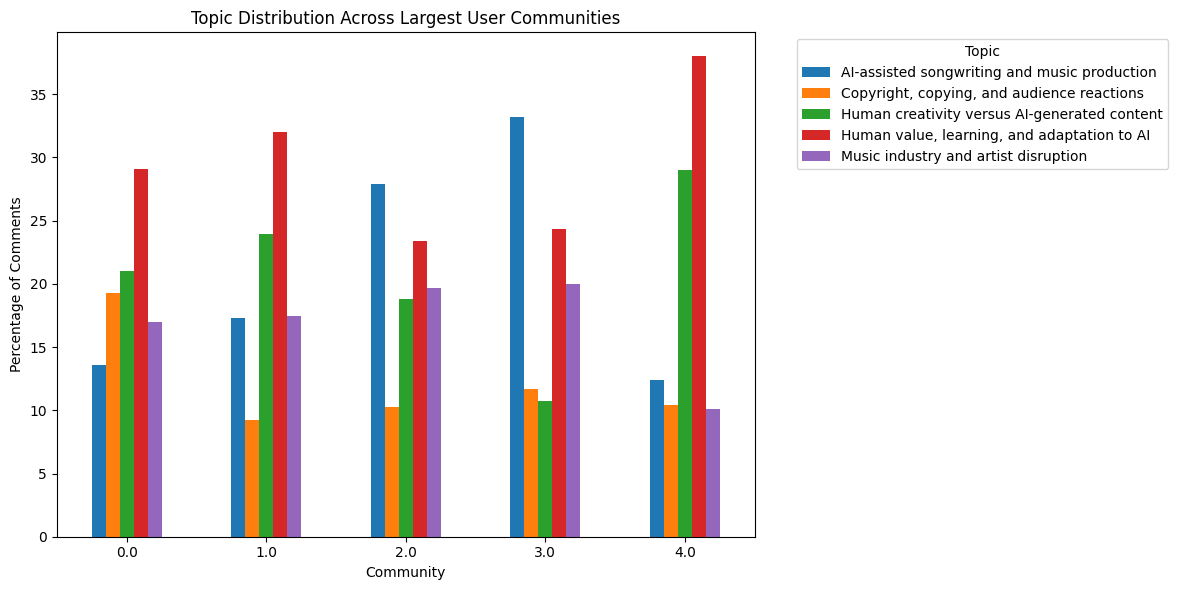

In [ ]:
# Plot larger communities per topic
pivot_community_topics = largest_community_topics.pivot(
    index='author_community',
    columns='topic_label',
    values='percentage'
).fillna(0)

pivot_community_topics.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Topic Distribution Across Larger User Communities')
plt.xlabel('Community')
plt.ylabel('Percentage of Comments')
plt.xticks(rotation=0)
plt.legend(title='Topic', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

The chart compares the dominant LDA topics across the five largest user communities detected in the YouTube reply network. Overall, the results suggest that different interaction communities focus on different aspects of AI’s impact on the music sector.

- Communities 0, 1, and 4 are most strongly associated with **“Human value, learning, and adaptation to AI”**, suggesting that many users in these groups discuss broader questions about how people, artists, and workers may adapt to AI technologies. This indicates that the discussion is not only about music production itself, but also about the wider social and human implications of generative AI.

- Community 3 has the highest proportion of comments related to **“AI-assisted songwriting and music production”**. This suggests that users in this community are more focused on the practical use of AI tools for creating songs, lyrics, melodies, and recordings. Compared with the other communities, this group appears more centred on AI as a music-making tool.

- Community 4 shows a particularly high proportion of comments about **“Human creativity versus AI-generated content”** as well as human adaptation. This may indicate that users in this cluster are actively debating whether AI-generated music can be considered creative, authentic, or comparable to human-made art.

- Across all five communities, **“Copying, copyright, and audience reactions”** appears consistently but is not the dominant topic in most groups. This suggests that copyright and copying are relevant concerns, but the larger discussion is more strongly shaped by human creativity, adaptation, and AI-assisted music creation.

Overall, this plot shows that the network communities are not identical in their discussion patterns. The combination of community detection and topic modelling helps show how different groups of users frame AI’s impact on the music sector in different ways.

In [64]:
# This table finds the most common topic inside each user community.
# It helps us summarise what each community mainly talks about.

top_topic_per_community = (
    community_topic_summary
    # Sort by community first, then by comment count from highest to lowest
    .sort_values(
        ['author_community', 'comment_count'],
        ascending=[True, False]
    )
    # For each community, keep only the topic with the highest comment count
    .groupby('author_community')
    .head(1)
    .reset_index(drop=True)
)

# Display only the largest 5 communities, because these are the ones shown in the plot
top_topic_per_community[
    top_topic_per_community['author_community'].isin(largest_communities)
]

,author_community,topic_label,comment_count,community_total,percentage
0,0.0,"Human value, learning, and adaptation to AI",216,742,29.11
1,1.0,"Human value, learning, and adaptation to AI",242,756,32.01
2,2.0,AI-assisted songwriting and music production,196,702,27.92
3,3.0,AI-assisted songwriting and music production,213,641,33.23
4,4.0,"Human value, learning, and adaptation to AI",266,700,38.00


In [69]:
"""
This section prints example comments from each of the largest communities.
The aim is to check whether the topic labels make sense when compared with real comments.
"""
for community_id in largest_communities:
    print(f'\n---------------------------')
    print(f'Community {int(community_id)}')

    # Select comments written by users in this community
    community_comments = dataset[
        dataset['author_community'] == community_id
    ]

    # Find the most common topic in this community
    most_common_topic = (
        community_comments['topic_label']
        .value_counts()
        .idxmax()
    )

    print(f'Most common topic: {most_common_topic}')
    print('\nExample comments:')

    # Select high-confidence comments from the dominant topic
    example_comments = (
        community_comments[
            community_comments['topic_label'] == most_common_topic
        ]
        .sort_values('dominant_topic_probability', ascending=False)
        .head(3)
    )

    # Print a short version of each example comment
    for _, row in example_comments.iterrows():
        print('-', row['text'][:300])


---------------------------
Community 1
Most common topic: Human value, learning, and adaptation to AI

Example comments:
- @skierpage They didn't say they were going to draw the line, but just pointed out that some line will be drawn. Also I want to say that no matter where that line is drawn there will be people on both sides saying it goes to far and also not far enough. Eventually some authority group will draw a lin
- @musicbro8225 "So you want new categories for theft and displacement of human creativity?" Yes. Because the old categories are not up to the current problem. "Plagiarism" has a legal definition, and I strongly doubt most of what AI can do that threaten's human creativity would meet that legal bar. S
- @sam_c95 what I enjoy about creative mediums is that they are a means for humans to communicate with each other in a way beyond words alone. I do not want to have these interactions with an emotionless, non-sentient thing like AI that tries to feign human-ness. I want 